# QC module

## 1 Functions and module

### 1.1 Modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
import numpy as np
import math
import seaborn as sns
import regex
from scipy import stats

In [2]:
pd.set_option('display.max_columns', 30)

### 1.2 Functions

In [3]:
def plot_unity(xdata, ydata, **kwargs):
    mn = min(xdata.min(), ydata.min())
    mx = max(xdata.max(), ydata.max())
    points = np.linspace(mn, mx, 100)
    plt.gca().plot(points, points, color='k', marker=None,
            linestyle='--', linewidth=1.0)


In [4]:
def Combine_DataFrame_Info(input_reads_df, input_gRNA_df, input_sample_df):
    # this function take reads, gRNA info df and sample df, and merge to a final data df
    # merge reads df with gRNA info df. Only gRNA match with reference will be selected
    temp_df = input_reads_df.merge(
        input_gRNA_df, how='inner', on=['gRNA'], sort=True)
    # merge reads df with sample info df
    output_df = temp_df.merge(
        input_sample_df, how='inner', on=['Sample_ID'], sort=True)
    output_df['gRNA_clonalbarcode'] = output_df['gRNA'] + '_' + output_df['Clonal_barcode']
    return (output_df)

In [5]:
def Generate_Raw_Dataframe(input_read_adress, input_gRNA_address, input_experiment_address,
                           barcode_pattern=False):
    combined_df = pd.read_csv(input_read_adress)
    combined_df = combined_df.rename(columns = {'Frequency':'Count'})

    # Read gRNA and spike in info
    gRNA_info_df = pd.read_csv(input_gRNA_address, header=None, skiprows=[0,],
                               names=['Targeted_gene_name', 'gRNA'])

    # I drop duplicated gRNA information
    gRNA_info_df.drop_duplicates(inplace=True)
    # add identity to distinguish gRNA and spikein
    gRNA_info_df['Identity'] = gRNA_info_df.apply(
        lambda x: x['Targeted_gene_name'] if (
            'Spike' in x['Targeted_gene_name']) else 'gRNA', axis=1)
    # added number for sgRNAs for the same targeting gene
    gRNA_info_df['Numbered_gene_name'] = gRNA_info_df['Targeted_gene_name']
    mask = gRNA_info_df['Numbered_gene_name'].duplicated(keep=False)
    gRNA_info_df.loc[mask, 'Numbered_gene_name'] += '_'+gRNA_info_df.groupby(
        'Numbered_gene_name').cumcount().add(1).astype(str)

    # read experiment information
    exp_info_df = pd.read_csv(
        input_experiment_address)

    # rename column names to make it consistent
    exp_info_df.rename(columns = {'Sample ID':'Sample_ID','Mouse_Genotype':'Mouse_genotype',
                                 'Virus_Titer':'Virus_titer','Time_After_Tumor_Initiation(wks)':'Time_after_tumor_initiation',
                                 'Total_Lung_Weight(g)':'Total_lung_weight'}, inplace = True)
    Output_df = Combine_DataFrame_Info(combined_df,gRNA_info_df,exp_info_df)
    if barcode_pattern:
    # Now I check the barcode of gRNA to see if they are saturation barcode
    # temp_pattern = regex.compile('(.{3}A.{2}C.{4}C.{3})')
        temp_pattern = regex.compile(barcode_pattern)
        Output_df['Barcode_pattern'] = ['Spikein_barcode']*Output_df.shape[0]
        temp_list = []
        for temp_b in Output_df.loc[Output_df['Identity']=='gRNA','Clonal_barcode']:
            if temp_pattern.search(temp_b):
                temp_list.append('Real')
            else:
                temp_list.append('Fake')
        Output_df.loc[Output_df['Identity']=='gRNA', 'Barcode_pattern'] = temp_list
        Output_df_s = Output_df[Output_df['Barcode_pattern']!='Fake']
    tv = combined_df['Count'].sum()
    print(f'There are totally {tv:.3e} reads')
    tv2 = Output_df_s['Count'].sum()
    print(f'There are {tv2:3e} reads mapped to barcode pattern, which is about {tv2/tv:f}')
    return (Output_df)

In [6]:
def Spikein_summary_immunoediting(input_df,input_spikein_name,input_cell_number):
# this function extract spike reads for each kind in each sample
    temp_df = input_df[input_df['Targeted_gene_name'].isin(input_spikein_name)] # select spike in rows
    temp_df = temp_df.groupby(['Sample_ID','Targeted_gene_name'],as_index = False).agg(
        Unique_spikein_barcode_number = pd.NamedAgg('Clonal_barcode',aggfunc = lambda x: len(x)), # number of different spike-in barcode
        Count = pd.NamedAgg('Count',aggfunc = np.sum)
    )
    temp_df['Cell_per_read'] = input_cell_number/temp_df['Count']
    temp_df['Amplification'] = temp_df.Count/temp_df.Unique_spikein_barcode_number
    return(temp_df)

In [7]:
# calculate the combined spikein metrics for each sample
def Cal_Spike_in_Ratio(x):
    d = {}
    temp_name_list = spikein_name_list # this is spike in name_list 
    temp_vect = x[['Targeted_gene_name','Count']]
    s1_value = x[x['Targeted_gene_name'] == temp_name_list[0]]['Count'].values[0]
    s2_value = x[x['Targeted_gene_name'] == temp_name_list[1]]['Count'].values[0]
    s3_value = x[x['Targeted_gene_name'] == temp_name_list[2]]['Count'].values[0]
    d['Spikein1'] = s1_value
    d['Spikein2'] = s2_value
    d['Spikein3'] = s3_value
    d['Mean_count'] = (s1_value+s2_value+s3_value)/3 # mean count for spike in 
    s1_s2_ratio =  s1_value/s2_value# spikein 1/ spikein 2 ratio
    s1_s3_ratio =  s1_value/s3_value# spikein 1/ spikein 2 ratio
    d['s1_s2_ratio'] = s1_s2_ratio
    d['s1_s3_ratio'] = s1_s3_ratio
    d['max_least_ratio'] = sorted([s1_value,s2_value,s3_value])[-1]/sorted([s1_value,s2_value,s3_value])[0]
    return pd.Series(d, index=list(d.keys())) 

In [8]:
def label_point(x, y, val, ax):
    a = pd.concat({'x': x, 'y': y, 'val': val}, axis=1)
    for i, point in a.iterrows():
        ax.text(point['x']+.02, point['y'], str(point['val']),size = 8)

In [9]:
def Generate_Simple_Sample_Summary(input_df,input_spikein_df):
    temp_df0 = input_df.groupby(['Sample_ID','Mouse_genotype','Virus_titer','Total_lung_weight','Mouse_Ear_Tag','Pooling_library_name'],as_index=False).agg(
        TTR = pd.NamedAgg('Count',aggfunc = sum)) # total reads
    spikein_name_list = ['Spike-in-1','Spike-in-2','Spike-in-3'] # spike in name should be ordered here
    temp_spike_df = input_spikein_df.set_index('Sample_ID')
    temp_df0['Spike1_reads_fraction'] = temp_spike_df[temp_spike_df['Targeted_gene_name']==spikein_name_list[0]].loc[temp_df0.Sample_ID]['Count'].to_list()/temp_df0.TTR
    temp_df0['Spike2_reads_fraction'] = temp_spike_df[temp_spike_df['Targeted_gene_name']==spikein_name_list[1]].loc[temp_df0.Sample_ID]['Count'].to_list()/temp_df0.TTR
    temp_df0['Spike3_reads_fraction'] = temp_spike_df[temp_spike_df['Targeted_gene_name']==spikein_name_list[2]].loc[temp_df0.Sample_ID]['Count'].to_list()/temp_df0.TTR
    return(temp_df0)

In [10]:
def Generate_Conversion_factor(input_spike_df, input_candidate_list, input_spike_in_list,temp_spikein_cell_number):
    # this function generate a df storing cell number per reads
    # input_spike_df is the df contain the spikein information (spikein_ratio_df)
    # temp_spikein_cell_number is the cell number for each spike in added into sample (usually it is 100K)
    # for most sample, I will use temp_spikein_cell_number/ mean(spike in reads)
    # input_candidate_list is the list of sample id whose spikein needed special treatment
    # temp_spikein_cell_number specify which spike in will be use for each sample ID who need special treatment
    input_dic = dict(zip(input_candidate_list, input_spike_in_list))
    temp_dic = {}
    for index,row in input_spike_df.iterrows():
        temp_id = row['Sample_ID']
        if temp_id in input_dic.keys():
            # print(row[input_dic.get(id)])
            temp_value = row[input_dic.get(temp_id)].mean()
        else:
            temp_value = row['Mean_count']
        temp_dic[temp_id] = temp_spikein_cell_number/temp_value
    temp_df = pd.DataFrame({'Sample_ID':temp_dic.keys(),
                       'Cell_number_per_read':temp_dic.values()})
    temp_df['Correction_for_spikein'] = temp_df['Sample_ID'].apply(lambda x: 'Yes' if (x in input_candidate_list) else 'No')
    return(temp_df.sort_values(by=['Correction_for_spikein','Cell_number_per_read']))
        

In [11]:
def Final_df_Generation(input_df,input_conversion_factor_df):
    # input_df is the dataframe input
    # input_conversion_factor_df is the dictionary that store the the cell number per reads
    temp_df = input_df.merge(input_conversion_factor_df, on ='Sample_ID')
    temp_df['Cell_number'] = temp_df['Count']*temp_df['Cell_number_per_read']
    return(temp_df)

In [12]:
# calculate the summary metrics for each sample
def Cal_Sample_Summary_immunoediting(x):
    d = {}
    temp_vect = x['Cell_number']
    if type (temp_vect) == 'int':
        temp_vect = [temp_vect]
    d['gRNA_recovered'] = len(x['gRNA'].unique())
    d['TTB'] = sum(temp_vect) # total mutational burdern 
    d['TTN'] = len(temp_vect) # this is total tumor number
    d['TTR'] = sum(x['Count'])
    return pd.Series(d, index=list(d.keys())) 

In [13]:
# calculate the summary metrics for each sample
def Cal_Sample_Summary(x):
    d = {}
    temp_vect = x['Cell_number']
    if type (temp_vect) == 'int':
        temp_vect = [temp_vect]
    d['gRNA_recovered'] = len(x['gRNA'].unique())
    d['TTB'] = sum(temp_vect) # total mutational burdern 
    d['TTN'] = len(temp_vect) # this is total tumor number
    return pd.Series(d, index=list(d.keys())) 

In [14]:
def Generate_Sample_Summary_immunoediting(input_df, input_spikein_check_df,input_cell_number_cutoff,input_read_cutoff):
    # input_cell_number_cutoff is the cell number cutoff
    # input_rad_cutoff is the read cutoff
    # Total reads does not restricted to gRNA or cell number cutoff
    temp_df0 = input_df.groupby(['Sample_ID','Mouse_Ear_Tag','Mouse_genotype', 'Sex','Pooling_library_name',
         'Time_after_tumor_initiation', 'Total_lung_weight', 'Virus_titer','Correction_for_spikein','Cell_number_per_read'],as_index=False).agg(
        TTR = pd.NamedAgg('Count',aggfunc = sum))
    temp_df0 = temp_df0.merge(input_spikein_check_df[['Sample_ID','Mean_count','max_least_ratio']],on = 'Sample_ID') # merge spike in info
    temp_df0['Spikein_read_ratio'] = (temp_df0['Mean_count']*3)/temp_df0['TTR']
    # filter input data
    temp_input = input_df[(input_df['Cell_number']>=input_cell_number_cutoff)&(input_df['Count']>input_read_cutoff)]
    # I only consider non-spikein gRNA
    temp_df1 = temp_input[temp_input['Identity']=='gRNA'].groupby(
        ['Sample_ID','Vector_ID'],as_index = False).apply(
        Cal_Sample_Summary_immunoediting)
    temp_df1['TTB_million'] = temp_df1['TTB']/1000000
    # merge sample and gRNA information    
    temp_df1 = temp_df1.merge(temp_df0.drop(columns='TTR'),on = 'Sample_ID',how = 'right')
    return(temp_df1)

In [15]:
def Generate_Sample_Summary(input_df, input_spikein_check_df,input_cell_number_cutoff,input_read_cutoff):
    # input_cell_number_cutoff is the cell number cutoff
    # input_rad_cutoff is the read cutoff
    # Total reads does not restricted to gRNA or cell number cutoff
    temp_df0 = input_df.groupby(['Sample_ID','Mouse_Ear_Tag','Mouse_genotype', 'Sex','Pooling_library_name',
         'Time_after_tumor_initiation', 'Total_lung_weight', 'Virus_titer','Correction_for_spikein','Cell_number_per_read'],as_index=False).agg(
        TTR = pd.NamedAgg('Count',aggfunc = sum))
    temp_df0 = temp_df0.merge(input_spikein_check_df[['Sample_ID','Mean_count','max_least_ratio']],on = 'Sample_ID') # merge spike in info
    temp_df0['Spikein_read_ratio'] = (temp_df0['Mean_count']*3)/temp_df0['TTR']
    # filter input data
    temp_input = input_df[(input_df['Cell_number']>=input_cell_number_cutoff)&(input_df['Count']>input_read_cutoff)]
    # I only consider non-spikein gRNA
    temp_df1 = temp_input[temp_input['Identity']=='gRNA'].groupby(
        ['Sample_ID'],as_index = False).apply(
        Cal_Sample_Summary)
    temp_df1['TTB_million'] = temp_df1['TTB']/1000000
    # merge sample and gRNA information    
    temp_df1 = temp_df1.merge(temp_df0,on = 'Sample_ID',how = 'right')
    return(temp_df1)

----

## 2 Input and output address

In [16]:
# combined barcode dataframe address
parent_address = "data/"
combined_df_address = parent_address + "gRNA_clonalbarcode_combined.csv"
# gRNA information address
gRNA_info_address = parent_address + "gRNA_information.csv"
# experimental information address
exp_info_address = parent_address + "Immunoediting_mice_info_standardized.csv"

In [17]:
Final_df_output_address = parent_address + "Immunoediting_raw_final_df.parquet"

-----

## 3 Raw data processing

### 3.1 Explaination and note
* <font size="5"> For the preliminary pipeline, only completely matched gRNAs and vector id are retained</font>
* <font size="5"> I can use the spike barcode to estimate mutation rate</font>

### 3.2 raw data Generation

In [18]:
temp_raw_summary_df = Generate_Raw_Dataframe(combined_df_address,gRNA_info_address,exp_info_address,barcode_pattern='(A|T|C){10}')

There are totally 5.139e+08 reads
There are 5.136934e+08 reads mapped to barcode pattern, which is about 0.999585


In [19]:
temp_raw_summary_df['Sample_ID'] = temp_raw_summary_df['Sample_ID'].astype('str')

In [20]:
temp_raw_summary_df = temp_raw_summary_df[~((temp_raw_summary_df['Identity']=='Spike-in')&(temp_raw_summary_df['Vector_ID']!='GAAA'))]

### 3.3 spike-in barcode mutation rate

* <font size="5" color = red> Spike-in barcode are 'CTATTAACAA', 'CCACTTTCCT', 'TACATTATTA'</font>

In [21]:
spikein_list = ['CTATTAACAA', 'CCACTTTCCT', 'TACATTATTA']
temp_raw_summary_df.loc[(temp_raw_summary_df.Identity=='Spike-in')&(temp_raw_summary_df.Clonal_barcode=='CTATTAACAA'),'Targeted_gene_name'] = 'Spike-in-1'
temp_raw_summary_df.loc[(temp_raw_summary_df.Identity=='Spike-in')&(temp_raw_summary_df.Clonal_barcode=='CTATTAACAA'),'Numbered_gene_name'] = 'Spike-in-1'
temp_raw_summary_df.loc[(temp_raw_summary_df.Identity=='Spike-in')&(temp_raw_summary_df.Clonal_barcode=='CCACTTTCCT'),'Targeted_gene_name'] = 'Spike-in-2'
temp_raw_summary_df.loc[(temp_raw_summary_df.Identity=='Spike-in')&(temp_raw_summary_df.Clonal_barcode=='CCACTTTCCT'),'Numbered_gene_name'] = 'Spike-in-2'
temp_raw_summary_df.loc[(temp_raw_summary_df.Identity=='Spike-in')&(temp_raw_summary_df.Clonal_barcode=='TACATTATTA'),'Targeted_gene_name'] = 'Spike-in-3'
temp_raw_summary_df.loc[(temp_raw_summary_df.Identity=='Spike-in')&(temp_raw_summary_df.Clonal_barcode=='TACATTATTA'),'Numbered_gene_name'] = 'Spike-in-3'
spikein_df = temp_raw_summary_df[temp_raw_summary_df.Identity!='gRNA']
nonspikein_df = temp_raw_summary_df[temp_raw_summary_df.Identity=='gRNA']
spikein_df = spikein_df[spikein_df.Clonal_barcode.isin(spikein_list)].sort_values(by='Count', ascending=False)

In [22]:
raw_summary_df = temp_raw_summary_df[(temp_raw_summary_df.Barcode_pattern!='Fake')&(temp_raw_summary_df.Targeted_gene_name!='Spike-in')]

## 4 Spikein QC

### 4.1 Count spikein read numbers and ratio

In [23]:
# I first check if spikes have similar read counts 
spikein_name_list = ['Spike-in-1','Spike-in-2','Spike-in-3'] # spike in name should be ordered here
spikein_df = Spikein_summary_immunoediting(raw_summary_df,spikein_name_list,500000)

In [24]:
spikein_ratio_df = spikein_df.groupby(['Sample_ID'],as_index = False).apply(Cal_Spike_in_Ratio) # the ratio of spike in

In [25]:
spikein_ratio_df.head()

,Sample_ID,Spikein1,Spikein2,Spikein3,Mean_count,s1_s2_ratio,s1_s3_ratio,max_least_ratio
0,28858,523508.0,1117815.0,485237.0,708853.333333,0.468332,1.078871,2.303647
1,28875,228674.0,335402.0,190827.0,251634.333333,0.681791,1.198331,1.757623
2,28878,429042.0,588498.0,310332.0,442624.000000,0.729046,1.382526,1.896350
3,29458,55324.0,77699.0,34051.0,55691.333333,0.712030,1.624739,2.281842
4,29462,41376.0,65329.0,29974.0,45559.666667,0.633348,1.380396,2.179522


### 4.2 Find samples with unusual spike in ratio

Text(0, 0.5, 's1/s3')

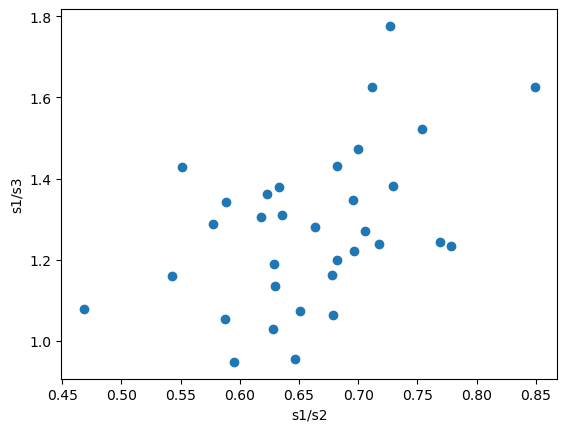

In [26]:
plt.scatter(spikein_ratio_df.s1_s2_ratio,spikein_ratio_df.s1_s3_ratio)
# label_point(spikein_ratio_df.s1_s2_ratio,spikein_ratio_df.s1_s3_ratio, spikein_ratio_df['Sample_ID'], plt.gca())
# plt.xscale('log',base = 2)
# plt.yscale('log',base = 2)
plt.xlabel('s1/s2')
plt.ylabel('s1/s3')

Text(0, 0.5, 's1/s3')

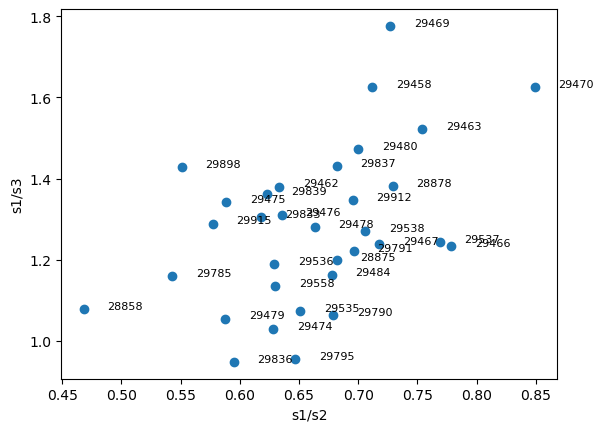

In [27]:
plt.scatter(spikein_ratio_df.s1_s2_ratio,spikein_ratio_df.s1_s3_ratio)
label_point(spikein_ratio_df.s1_s2_ratio,spikein_ratio_df.s1_s3_ratio, spikein_ratio_df['Sample_ID'], plt.gca())
# plt.xscale('log',base = 2)
# plt.yscale('log',base = 2)
plt.xlabel('s1/s2')
plt.ylabel('s1/s3')

* <font size="5" color =  black> All looks good to me</font>

### 4.3 Find bad spike in for those samples

#### 4.3.1 Method 1

In [28]:
input_ratio_cutoff = 2.5 # this is the cutoff 
temp_bad_list = spikein_ratio_df.loc[spikein_ratio_df['max_least_ratio']>input_ratio_cutoff,'Sample_ID'].to_list() # list of sample with bad spikein

/var/folders/xv/26kbh4lj2rjdcrxz37m9wxyw0000gn/T/ipykernel_1439/1708176043.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  x.set_xticklabels(['spike_in_1','spike_in_2','spike_in_3'])


Text(0.5, 0.95, 'Samples with unexpected spike-in ratio (>2.5)')

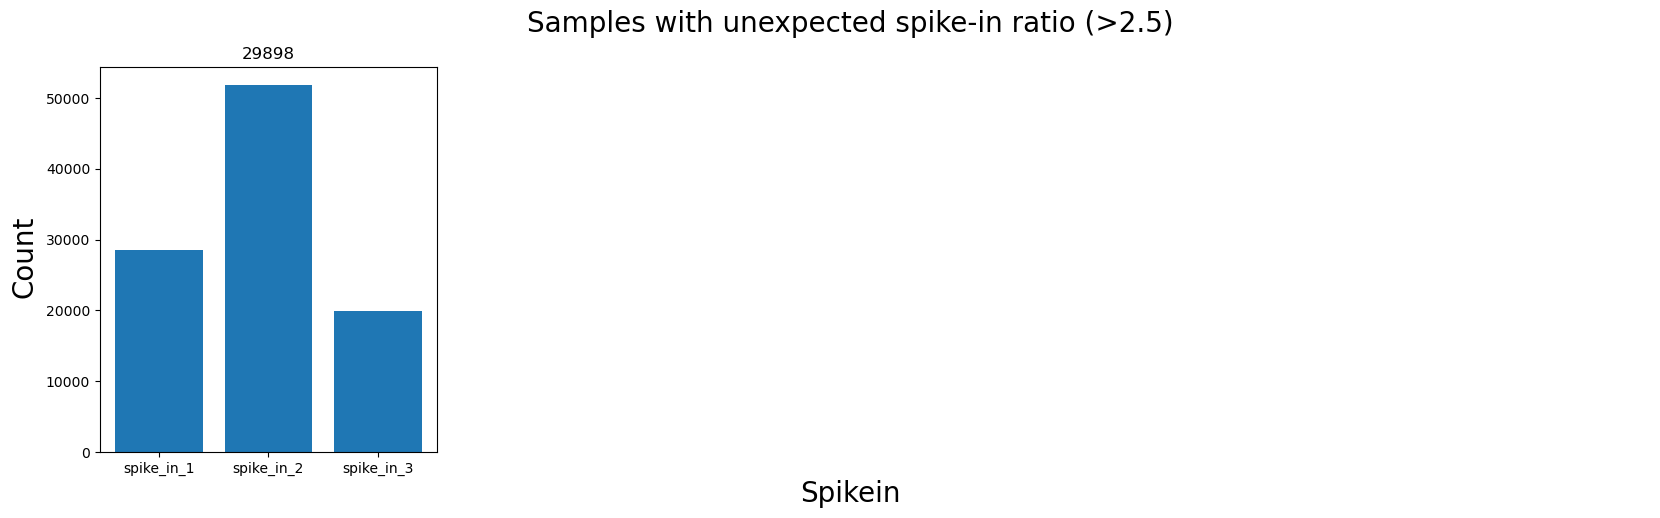

In [29]:
# check the max/min ratio in each sample and print those sample with ratio above certain cutoff
fig1,ax = plt.subplots(math.ceil(len(temp_bad_list)/4), 4, figsize=(20,5*math.ceil(len(temp_bad_list)/4)))
axes = ax.flatten()
for x,y in zip(axes[:len(temp_bad_list)],temp_bad_list):
    temp_df = spikein_df[spikein_df['Sample_ID'] == y]
    x.bar(temp_df['Targeted_gene_name'],temp_df['Count'])
    x.set_title(y)
    x.set_xticklabels(['spike_in_1','spike_in_2','spike_in_3'])
for x in axes[len(temp_bad_list):]:
    x.set_axis_off()
fig1.text(0.08, 0.5, 'Count', va='center', rotation='vertical',fontsize=20)
fig1.text(0.5, 0.01, 'Spikein', ha='center',fontsize=20)
fig1.text(0.5, 0.95, 'Samples with unexpected spike-in ratio (>{})'.format(input_ratio_cutoff), ha='center',fontsize=20)
# fig1.savefig(figure_output_address+'QC_332.pdf')aa

* <font size="5" color =  black> If we assume only one of the spikein has a problem, the one with extraordinary <mark> high </mark> count seems to be the problematic one</font>
* <font size="5" color =  black> <mark> 29898 </mark> has a higher spike-in-2 count</font>
* <font size="5" color =  black> Because they are not too distorted (ratio between spike in >3). So I will not correct them</font>

#### 4.3.2 Method 2

In [30]:
temp_summary_df = Generate_Simple_Sample_Summary(raw_summary_df,spikein_df)

In [31]:
temp_summary_df.head()

,Sample_ID,Mouse_genotype,Virus_titer,Total_lung_weight,Mouse_Ear_Tag,Pooling_library_name,TTR,Spike1_reads_fraction,Spike2_reads_fraction,Spike3_reads_fraction
0,28858,KT,"300,000",0.3189,28858.0,Library 1,23853949,0.021946,0.046861,0.020342
1,28875,KT,"300,000",0.4423,28875.0,Library 1,15803775,0.014470,0.021223,0.012075
2,28878,KT,"300,000",0.2928,28878.0,Library 1,17045054,0.025171,0.034526,0.018207
3,29458,KTC,"180,000",0.3688,29458.0,Library 1,20824611,0.002657,0.003731,0.001635
4,29462,KTC,"180,000",0.5387,29462.0,Library 1,12298566,0.003364,0.005312,0.002437


<Axes: xlabel='Mouse_genotype', ylabel='Spike1_reads_fraction'>

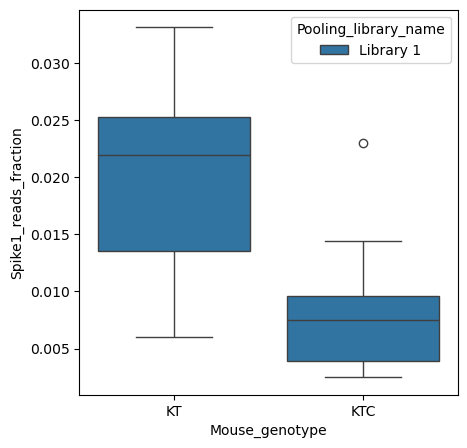

In [32]:
gs = gridspec.GridSpec(1, 17) 
fig1 = plt.figure(figsize=(17,5))
ax1=fig1.add_subplot(gs[:1, 0:5])
temp_df = temp_summary_df
ix = 'Mouse_genotype'
iy = 'Spike1_reads_fraction'
# sns.scatterplot(data=temp_df, x=ix,y =iy ,ax = ax1,hue = 'Pooling_library_name',)
sns.boxplot(data=temp_df, x=ix,y =iy ,hue = 'Pooling_library_name', ax = ax1)
# ax1.set_yscale('log', base=10)

In [33]:
temp_df.groupby('Mouse_genotype', as_index=False)['Spike1_reads_fraction'].mean()

,Mouse_genotype,Spike1_reads_fraction
0,KT,0.019801
1,KTC,0.007601


In [34]:
temp_df.groupby('Mouse_genotype', as_index=False)['Spike2_reads_fraction'].mean()

,Mouse_genotype,Spike2_reads_fraction
0,KT,0.030614
1,KTC,0.011593


In [35]:
temp_df.groupby('Mouse_genotype', as_index=False)['Spike3_reads_fraction'].mean()

,Mouse_genotype,Spike3_reads_fraction
0,KT,0.016483
1,KTC,0.006081


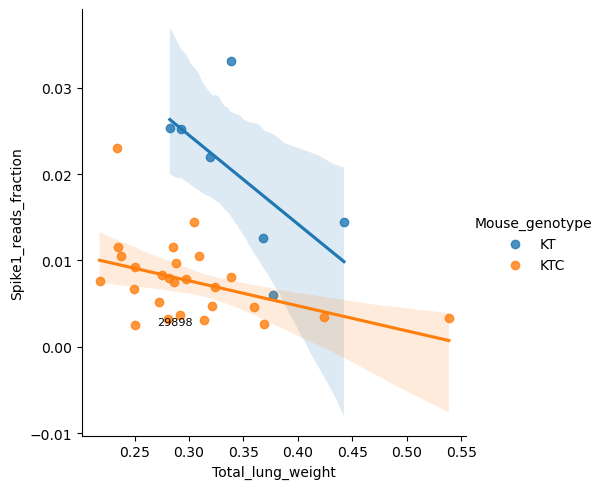

In [36]:
temp_df = temp_summary_df
ix = 'Total_lung_weight'
iy = 'Spike1_reads_fraction'
# sns.scatterplot(data=temp_df, x=ix,y =iy ,ax = ax1,hue = 'Pooling_library_name',)
sns.lmplot(data=temp_df, x=ix,y =iy ,hue = 'Mouse_genotype')
temp_sub = temp_df[temp_df.Sample_ID.isin(temp_bad_list)]
label_point(temp_sub[ix],temp_sub[iy], temp_sub['Sample_ID'], plt.gca())

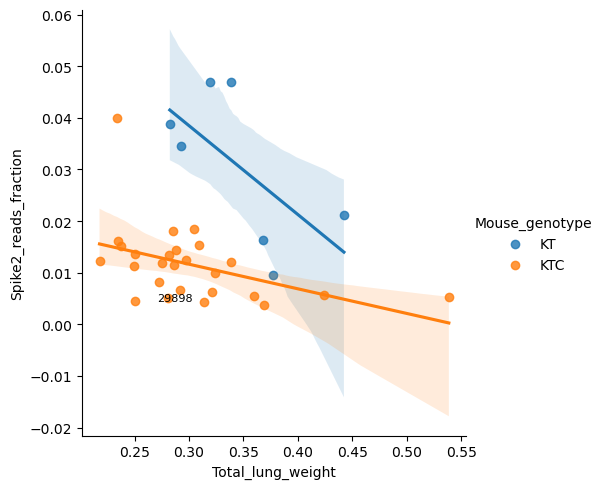

In [37]:
temp_df = temp_summary_df
ix = 'Total_lung_weight'
iy = 'Spike2_reads_fraction'
# sns.scatterplot(data=temp_df, x=ix,y =iy ,ax = ax1,hue = 'Pooling_library_name',)
sns.lmplot(data=temp_df, x=ix,y =iy ,hue = 'Mouse_genotype')
temp_sub = temp_df[temp_df.Sample_ID.isin(temp_bad_list)]
label_point(temp_sub[ix],temp_sub[iy], temp_sub['Sample_ID'], plt.gca())

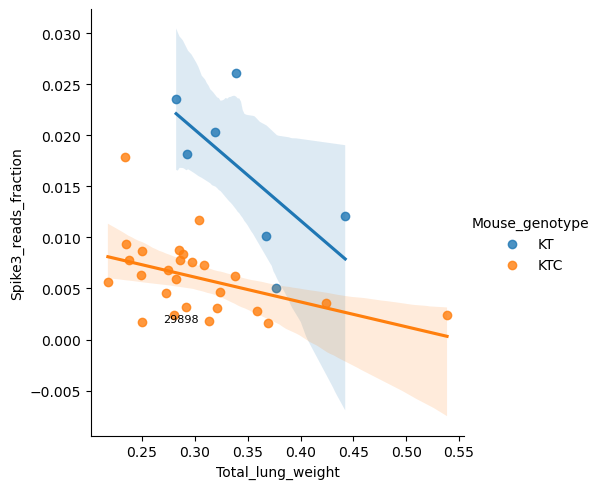

In [38]:
temp_df = temp_summary_df
ix = 'Total_lung_weight'
iy = 'Spike3_reads_fraction'
# sns.scatterplot(data=temp_df, x=ix,y =iy ,ax = ax1,hue = 'Pooling_library_name',)
sns.lmplot(data=temp_df, x=ix,y =iy ,hue = 'Mouse_genotype')
temp_sub = temp_df[temp_df.Sample_ID.isin(temp_bad_list)]
label_point(temp_sub[ix],temp_sub[iy], temp_sub['Sample_ID'], plt.gca())

In [39]:
temp_summary_df['R_L_ratio'] = temp_summary_df.TTR/(temp_summary_df.Total_lung_weight-0.15)

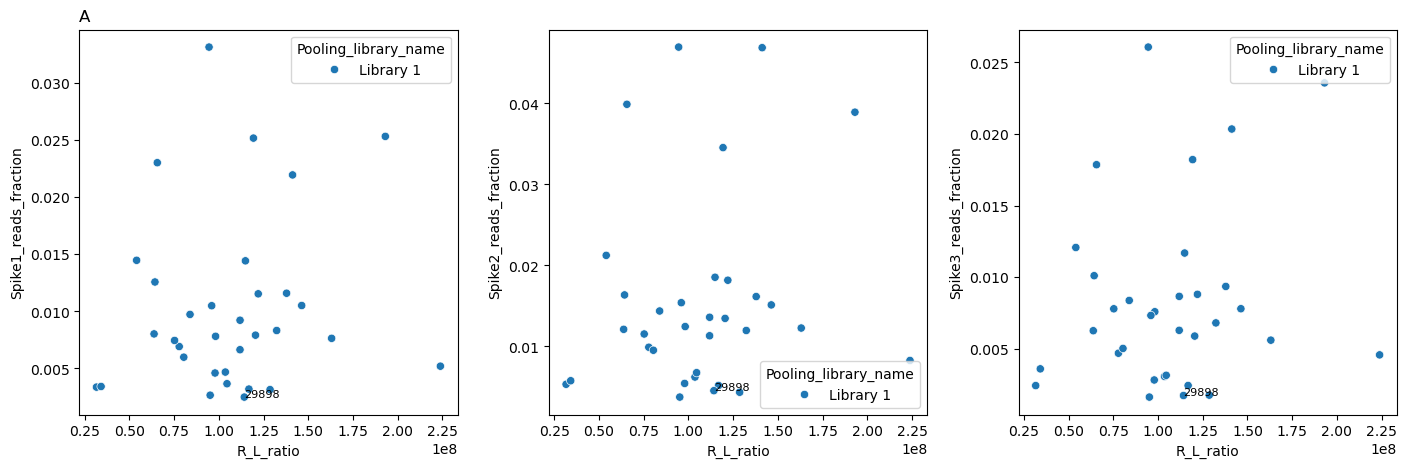

In [40]:
gs = gridspec.GridSpec(1, 17) 
fig1 = plt.figure(figsize=(17,5))

ax1=fig1.add_subplot(gs[:1, 0:5])
temp_df = temp_summary_df
ix = 'R_L_ratio'
iy = 'Spike1_reads_fraction'
sns.scatterplot(data=temp_df, x=ix,y =iy ,ax = ax1,hue = 'Pooling_library_name',)
# sns.regplot(data=temp_df, x=ix,y =iy ,ax = ax1,hue = 'Pooling_library_name')
temp_sub = temp_df[temp_df.Sample_ID.isin(temp_bad_list)]
label_point(temp_sub[ix],temp_sub[iy], temp_sub['Sample_ID'], plt.gca())


# ax1.set_xlabel('Total lung weight')
ax1.set_ylabel(iy)
# ax1.set_yscale('log')
ax1.set_title('A', loc ='left')


ax2=fig1.add_subplot(gs[:1, 6:11])
temp_df = temp_summary_df
ix = 'R_L_ratio'
iy = 'Spike2_reads_fraction'
sns.scatterplot(data=temp_df, x=ix,y =iy ,ax = ax2,hue = 'Pooling_library_name')
temp_sub = temp_df[temp_df.Sample_ID.isin(temp_bad_list)]
label_point(temp_sub[ix],temp_sub[iy], temp_sub['Sample_ID'], plt.gca())

# ax2.set_yscale('log')
# ax2.set_xlabel('Total lung weight')
# ax2.set_ylabel('Total tumor burden (million cells)')
# ax2.set_title('B', loc ='Left')


ax3 = fig1.add_subplot(gs[:1, 12:17])
temp_df = temp_summary_df
ix = 'R_L_ratio'
iy = 'Spike3_reads_fraction'
sns.scatterplot(data=temp_df, x=ix,y =iy ,ax = ax3,hue = 'Pooling_library_name')
temp_sub = temp_df[temp_df.Sample_ID.isin(temp_bad_list)]
label_point(temp_sub[ix],temp_sub[iy], temp_sub['Sample_ID'], plt.gca())

# ax3.set_yscale('log')

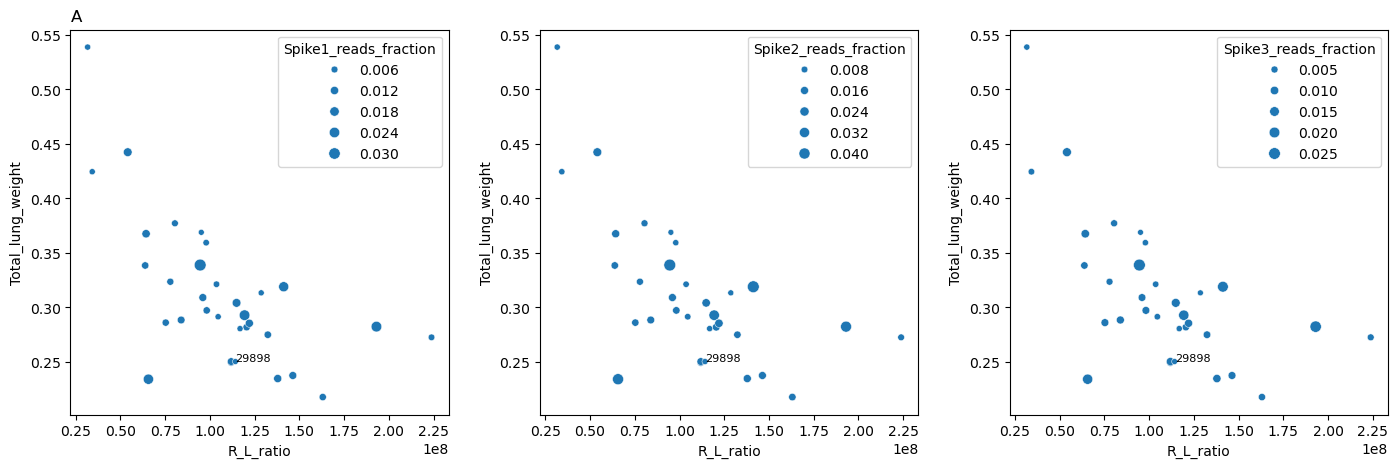

In [41]:
gs = gridspec.GridSpec(1, 17) 
fig1 = plt.figure(figsize=(17,5))

ax1=fig1.add_subplot(gs[:1, 0:5])
temp_df = temp_summary_df
ix = 'R_L_ratio'
iy = 'Total_lung_weight'
sns.scatterplot(data=temp_df, x=ix,y =iy ,ax = ax1,size = 'Spike1_reads_fraction',)
# sns.regplot(data=temp_df, x=ix,y =iy ,ax = ax1,hue = 'Pooling_library_name')
temp_sub = temp_df[temp_df.Sample_ID.isin(temp_bad_list)]
label_point(temp_sub[ix],temp_sub[iy], temp_sub['Sample_ID'], plt.gca())


ax1.set_xlabel(ix)
ax1.set_ylabel(iy)
# ax1.set_yscale('log')
ax1.set_title('A', loc ='left')


ax2=fig1.add_subplot(gs[:1, 6:11])
temp_df = temp_summary_df
ix = 'R_L_ratio'
iy = 'Total_lung_weight'
sns.scatterplot(data=temp_df, x=ix,y =iy ,ax = ax2,size = 'Spike2_reads_fraction')
temp_sub = temp_df[temp_df.Sample_ID.isin(temp_bad_list)]
label_point(temp_sub[ix],temp_sub[iy], temp_sub['Sample_ID'], plt.gca())

# ax2.set_yscale('log')
# ax2.set_xlabel('Total lung weight')
# ax2.set_ylabel('Total tumor burden (million cells)')
# ax2.set_title('B', loc ='Left')


ax3 = fig1.add_subplot(gs[:1, 12:17])
temp_df = temp_summary_df
ix = 'R_L_ratio'
iy = 'Total_lung_weight'
sns.scatterplot(data=temp_df, x=ix,y =iy ,ax = ax3,size = 'Spike3_reads_fraction')
temp_sub = temp_df[temp_df.Sample_ID.isin(temp_bad_list)]
label_point(temp_sub[ix],temp_sub[iy], temp_sub['Sample_ID'], plt.gca())

# ax3.set_yscale('log')

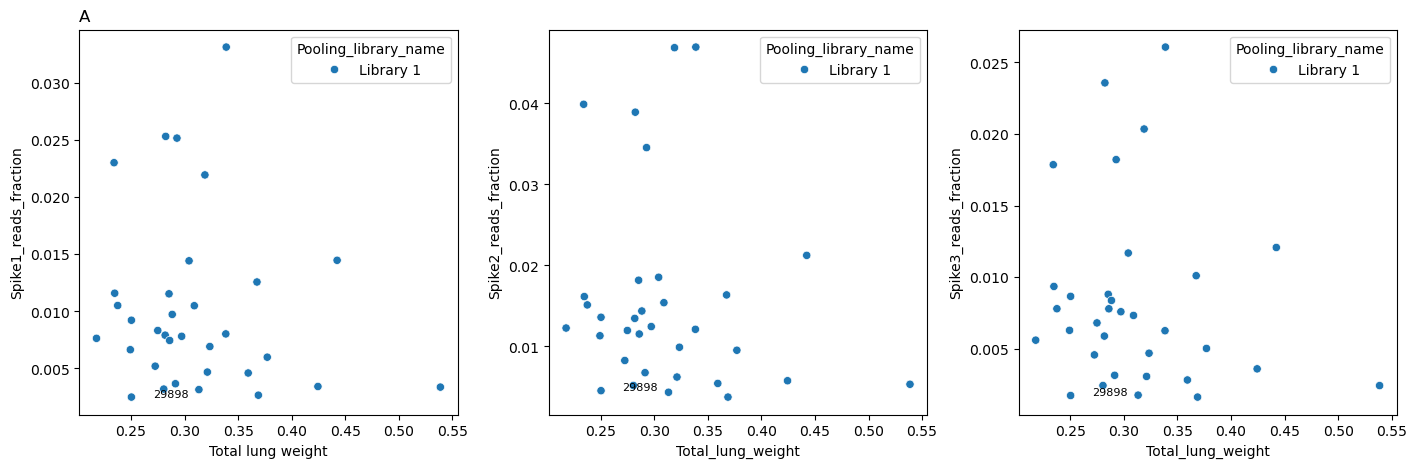

In [42]:
gs = gridspec.GridSpec(1, 17) 
fig1 = plt.figure(figsize=(17,5))

ax1=fig1.add_subplot(gs[:1, 0:5])
temp_df = temp_summary_df
ix = 'Total_lung_weight'
iy = 'Spike1_reads_fraction'
sns.scatterplot(data=temp_df, x=ix,y =iy ,ax = ax1,hue = 'Pooling_library_name',)
# sns.regplot(data=temp_df, x=ix,y =iy ,ax = ax1,hue = 'Pooling_library_name')
temp_sub = temp_df[temp_df.Sample_ID.isin(temp_bad_list)]
label_point(temp_sub[ix],temp_sub[iy], temp_sub['Sample_ID'], plt.gca())


ax1.set_xlabel('Total lung weight')
ax1.set_ylabel(iy)
# ax1.set_yscale('log')
ax1.set_title('A', loc ='left')


ax2=fig1.add_subplot(gs[:1, 6:11])
temp_df = temp_summary_df
ix = 'Total_lung_weight'
iy = 'Spike2_reads_fraction'
sns.scatterplot(data=temp_df, x=ix,y =iy ,ax = ax2,hue = 'Pooling_library_name')
temp_sub = temp_df[temp_df.Sample_ID.isin(temp_bad_list)]
label_point(temp_sub[ix],temp_sub[iy], temp_sub['Sample_ID'], plt.gca())

# ax2.set_yscale('log')
# ax2.set_xlabel('Total lung weight')
# ax2.set_ylabel('Total tumor burden (million cells)')
# ax2.set_title('B', loc ='Left')


ax3 = fig1.add_subplot(gs[:1, 12:17])
temp_df = temp_summary_df
ix = 'Total_lung_weight'
iy = 'Spike3_reads_fraction'
sns.scatterplot(data=temp_df, x=ix,y =iy ,ax = ax3,hue = 'Pooling_library_name')
temp_sub = temp_df[temp_df.Sample_ID.isin(temp_bad_list)]
label_point(temp_sub[ix],temp_sub[iy], temp_sub['Sample_ID'], plt.gca())

# ax3.set_yscale('log')

## 5 Correct Cell per reads

In [43]:
temp = []
conversion_factor_df= Generate_Conversion_factor(spikein_ratio_df,[],temp,500000)

In [44]:
conversion_factor_df.head()

,Sample_ID,Cell_number_per_read,Correction_for_spikein
17,29535,0.668937,No
0,28858,0.705365,No
20,29538,0.791681,No
2,28878,1.129627,No
6,29466,1.898316,No


In [45]:
Final_df = Final_df_Generation(raw_summary_df,conversion_factor_df)

## 6 Output 

In [46]:
temp_dic = {'AGTA':'NI', 'GAAA':'MI',
           'GATA':'HI'}

In [47]:
temp_list = Final_df.Vector_ID.apply(lambda x: temp_dic.get(x))
Final_df['Vector_type'] = temp_list 

In [48]:
Final_df.to_parquet(Final_df_output_address,index=False)

In [49]:
Final_HI_df_output_address = 'data/Immunoediting_HI_final_df.csv'
Final_NI_df_output_address = 'data/Immunoediting_NI_final_df.csv'
Final_MI_df_output_address = 'data/Immunoediting_MI_final_df.csv'

In [50]:
Final_df[Final_df.Vector_type=='NI'].to_csv(Final_NI_df_output_address, index=False)
Final_df[Final_df.Vector_type=='MI'].to_csv(Final_MI_df_output_address, index=False)
Final_df[Final_df.Vector_type=='HI'].to_csv(Final_HI_df_output_address, index=False)

## 7 Overall sample QC 

In [51]:
cell_number_cutoff = 100
temp = Final_df[Final_df.Identity=='gRNA']
Sample_summary_df =  Generate_Sample_Summary(temp, spikein_ratio_df,cell_number_cutoff,3)

### 7.2 Plot

Text(0, 0.5, 'Total tumor number')

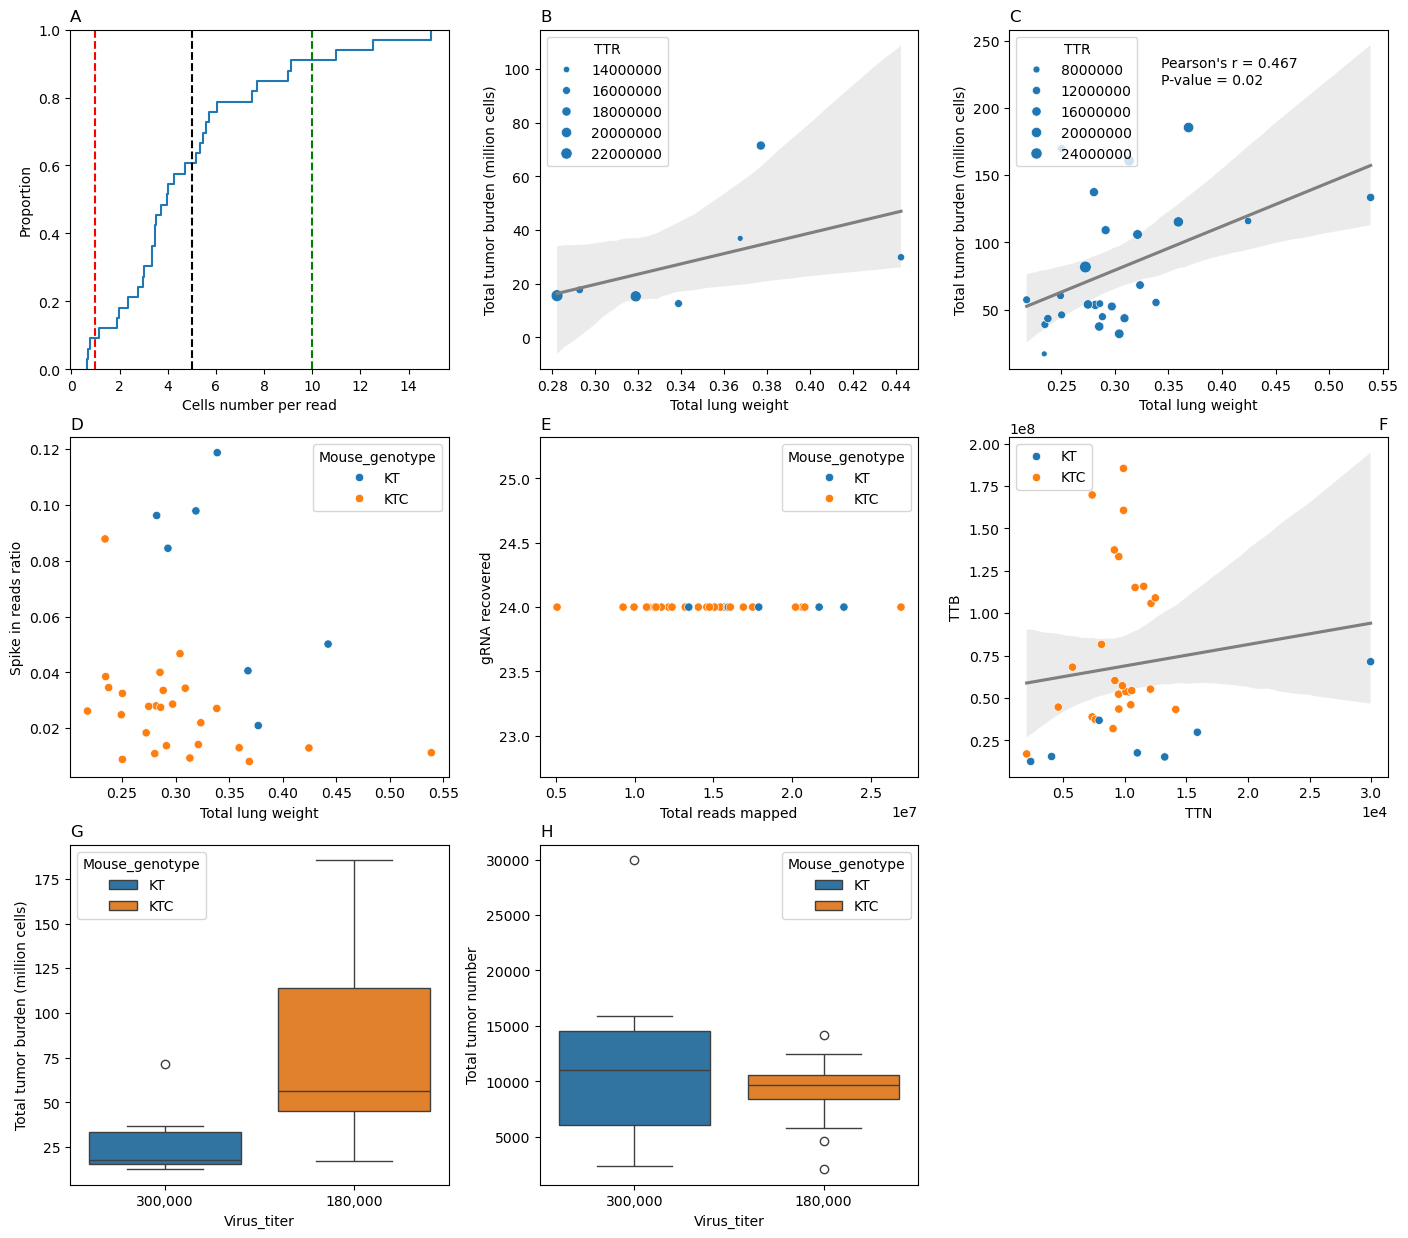

In [52]:
gs = gridspec.GridSpec(3, 17) 
fig1 = plt.figure(figsize=(17,15))

ax1=fig1.add_subplot(gs[:1, 0:5])
temp_df = Sample_summary_df
sns.ecdfplot(data=temp_df, x="Cell_number_per_read",ax = ax1)
ax1.set_xlabel('Cells number per read')
# ax1.set_xscale('log')
ax1.axvline(1,color='red', linestyle='--')
ax1.axvline(5,color='black', linestyle='--')
ax1.axvline(10,color='green', linestyle='--')
ax1.set_title('A', loc ='left')


ax2=fig1.add_subplot(gs[:1, 6:11])
temp_df = Sample_summary_df[(Sample_summary_df['Mouse_genotype']=='KT')]
sns.regplot(x='Total_lung_weight', y='TTB_million', data=temp_df, fit_reg=True ,ax= ax2,scatter=False,color = 'tab:grey')
sns.scatterplot(x='Total_lung_weight', y='TTB_million', data=temp_df,ax = ax2,size= 'TTR')
# label_point(temp_df['Total_lung_weight'], temp_df['TTB_million'], temp_df['Sample_ID'], plt.gca()) # this is for labeling
ax2.set_xlabel('Total lung weight')
ax2.set_ylabel('Total tumor burden (million cells)')
ax2.set_title('B', loc ='Left')

ax3=fig1.add_subplot(gs[:1, 12:17])
temp_df = Sample_summary_df[(Sample_summary_df['Mouse_genotype']=='KTC')]
sns.regplot(x='Total_lung_weight', y='TTB_million', data=temp_df, fit_reg=True ,ax= ax3,scatter=False,color = 'tab:grey')
temp1 = stats.pearsonr(temp_df['Total_lung_weight'],temp_df['TTB_million'])[0]
temp2 = stats.pearsonr(temp_df['Total_lung_weight'],temp_df['TTB_million'])[1]
ax3.text(0.40,0.9, "Pearson's r = "+str(round(temp1,3)), size=10, ha="left",verticalalignment='center', transform=ax3.transAxes)
ax3.text(0.40,0.85, f"P-value = {temp2:.2f}", size=10, ha="left",verticalalignment='center', transform=ax3.transAxes)

sns.scatterplot(x='Total_lung_weight', y='TTB_million', data=temp_df,ax = ax3,size= 'TTR')
# label_point(temp_df['Total_lung_weight'], temp_df['TTB_million'], temp_df['Sample_ID'], plt.gca()) # this is for labeling
ax3.set_xlabel('Total lung weight')
ax3.set_ylabel('Total tumor burden (million cells)')
ax3.set_title('C', loc ='Left')


ax4 = fig1.add_subplot(gs[1:2, 0:5])
sns.scatterplot(x='Total_lung_weight', y='Spikein_read_ratio', data=Sample_summary_df, hue='Mouse_genotype', ax= ax4)
temp_df = Sample_summary_df[Sample_summary_df.TTR<100000] # < 0.1 million reads
label_point(temp_df['TTR'], temp_df['Spikein_read_ratio'], temp_df['Sample_ID'], plt.gca()) # this is for labeling
# ax4.set_yscale('log')
ax4.set_title('D', loc ='Left')
ax4.set_xlabel('Total lung weight')
ax4.set_ylabel('Spike in reads ratio')




ax5 = fig1.add_subplot(gs[1:2, 6:11])

sns.scatterplot(x='TTR', y='gRNA_recovered',data=Sample_summary_df,hue='Mouse_genotype', ax= ax5)

temp_df = Sample_summary_df[Sample_summary_df.gRNA_recovered<24] # < 1 million reads
label_point(temp_df['TTR'], temp_df['gRNA_recovered'], temp_df['Sample_ID'], plt.gca()) # this is for labeling

ax5.set_xlabel('Total reads mapped')
ax5.set_ylabel('gRNA recovered')
ax5.set_title('E', loc ='left')


temp_df = Sample_summary_df
# temp_df = Sample_summary_df[Sample_summary_df.TTR>1000000]# I request at least 1 million reads
ax6 = fig1.add_subplot(gs[1:2, 12:17])
sns.regplot(x='TTN', y='TTB', data=temp_df, fit_reg=True ,ax= ax6,scatter=False,color = 'tab:grey')
sns.scatterplot(x='TTN', y='TTB', data=temp_df, hue='Mouse_genotype', ax= ax6)
# ax6.set_yscale('log')
ax6.set_title('F', loc ='Right')
ax6.set_xlabel('TTN')
ax6.set_ylabel('TTB')
# ax6.xaxis.major.formatter._useMathText = True
ax6.ticklabel_format(axis='both',style='sci',scilimits=(-3,4))
ax6.legend(loc='upper left')


ax7 = fig1.add_subplot(gs[2:3, :5])
# sns.boxplot(x='Virus_titer', y='TTB_million', data=Sample_summary_df, hue=Sample_summary_df[['Mouse_genotype','Sex']].apply(tuple, axis=1), ax= ax7)
sns.boxplot(x='Virus_titer', y='TTB_million', data=Sample_summary_df, hue='Mouse_genotype', ax= ax7)
ax7.set_title('G', loc ='left')
ax7.set_ylabel('Total tumor burden (million cells)')

ax8 = fig1.add_subplot(gs[2:3, 6:11])
# sns.boxplot(x='Virus_titer', y='TTN', data=Sample_summary_df, hue=Sample_summary_df[['Mouse_genotype','Sex']].apply(tuple, axis=1), ax= ax8)
sns.boxplot(x='Virus_titer', y='TTN', data=Sample_summary_df, hue='Mouse_genotype', ax= ax8)
ax8.set_title('H', loc ='Left')
ax8.set_ylabel('Total tumor number')

# ax9 = fig1.add_subplot(gs[2:3, 12:17])
# sns.scatterplot(x='R_L_ratio', y='Spikein_read_ratio', data=Sample_summary_df, hue='Mouse_genotype', ax= ax9)
# ax9.set_title('I', loc ='right')
# ax9.set_xlabel('Reads/lung weight ratio')
# test_df = Sample_summary_df[Sample_summary_df.Spikein_read_ratio>0.004]
# label_point(test_df['R_L_ratio'], test_df['Spikein_read_ratio'], test_df['Sample_ID'], plt.gca()) # this is for labeling
# ax9.set_ylabel('Spike in ratio')
# fig1.savefig(figure_output_address+'Overall_QC_Immunoediting.pdf')


In [53]:
Sample_summary_df.sort_values(by = 'TTR')

,Sample_ID,gRNA_recovered,TTB,TTN,TTB_million,Mouse_Ear_Tag,Mouse_genotype,Sex,Pooling_library_name,Time_after_tumor_initiation,Total_lung_weight,Virus_titer,Correction_for_spikein,Cell_number_per_read,TTR,Mean_count,max_least_ratio,Spikein_read_ratio
32,29915,24.0,1.706717e+07,2072.0,17.067173,29915.0,KTC,F,Library 1,12.0,0.2341,"180,000",No,3.365749,5073968,148555.333333,2.233496,0.087834
27,29836,24.0,1.158369e+08,11554.0,115.836916,29836.0,KTC,F,Library 1,12.0,0.4244,"180,000",No,12.508965,9268036,39971.333333,1.681497,0.012938
25,29795,24.0,5.440130e+07,10579.0,54.401300,29795.0,KTC,F,Library 1,12.0,0.2860,"180,000",No,5.473414,9965205,91350.666667,1.546139,0.027501
29,29839,24.0,5.728302e+07,9826.0,57.283022,29839.0,KTC,F,Library 1,12.0,0.2177,"180,000",No,5.328786,10758149,93830.000000,2.185400,0.026165
14,29479,24.0,6.033335e+07,9216.0,60.333346,29479.0,KTC,F,Library 1,12.0,0.2493,"180,000",No,5.572769,10837779,89722.000000,1.795762,0.024836
23,29790,24.0,4.605740e+07,10507.0,46.057405,29790.0,KTC,F,Library 1,12.0,0.2503,"180,000",No,4.248004,10868244,117702.333333,1.567853,0.032490
16,29484,24.0,4.468240e+07,4629.0,44.682399,29484.0,KTC,M,Library 1,12.0,0.2884,"180,000",No,3.977915,11237675,125694.000000,1.713490,0.033555
7,29467,24.0,3.889629e+07,7376.0,38.896289,29467.0,KTC,M,Library 1,12.0,0.2347,"180,000",No,3.463619,11245919,144357.666667,1.724907,0.038509
30,29898,24.0,1.697229e+08,7378.0,169.722852,29898.0,KTC,F,Library 1,12.0,0.2503,"180,000",No,14.946492,11359254,33452.666667,2.592756,0.008835
13,29478,24.0,5.526837e+07,12099.0,55.268367,29478.0,KTC,M,Library 1,12.0,0.3384,"180,000",No,4.728356,11706199,105745.000000,1.930120,0.027100


### 7.4 Output

In [54]:
Sample_summary_df.to_csv("data/Immunoediting_sample_summary_df.csv", index=False)

## 8 Overall sample QC considering vector ID

In [55]:
cell_number_cutoff = 100
temp = Final_df[Final_df.Identity=='gRNA']
Sample_summary_df2 =  Generate_Sample_Summary_immunoediting(temp, spikein_ratio_df,cell_number_cutoff,3)

In [56]:
temp_dic = {'AGTA':'NI', 'GAAA':'MI',
           'GATA':'HI'}

In [57]:
temp_list = Sample_summary_df2.Vector_ID.apply(lambda x: temp_dic.get(x))
Sample_summary_df2['Vector_type'] = temp_list 

### Do all sgRNA recovered for each vector?

Text(0.0, 1.0, 'A')

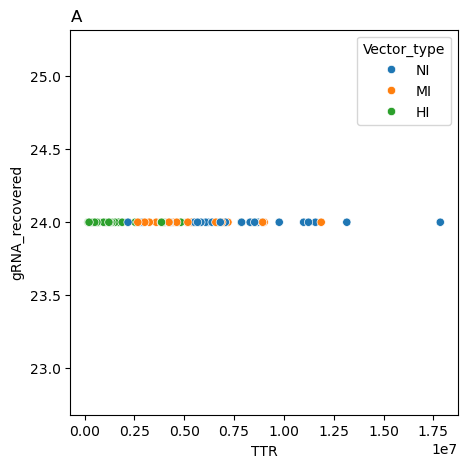

In [58]:
gs = gridspec.GridSpec(1, 5) 
fig1 = plt.figure(figsize=(5,5))

ax1=fig1.add_subplot(gs[:1, 0:5])
temp_df = Sample_summary_df2
sns.scatterplot(x='TTR', y='gRNA_recovered',data=temp_df,hue='Vector_type', ax= ax1)

temp_df = Sample_summary_df[Sample_summary_df.gRNA_recovered<24] # < 1 million reads
label_point(temp_df['TTR'], temp_df['gRNA_recovered'], temp_df['Sample_ID'], plt.gca()) # this is for labeling
# ax1.set_xscale('log')

ax1.set_title('A', loc ='left')

### How correlate it is for three immunoediting condition across mice

#### Total tumor number

In [59]:
temp_df = Sample_summary_df2
re_shaped_df = pd.pivot_table(temp_df, values = 'TTN', index=['Sample_ID','Mouse_genotype'], columns = 'Vector_type').reset_index()

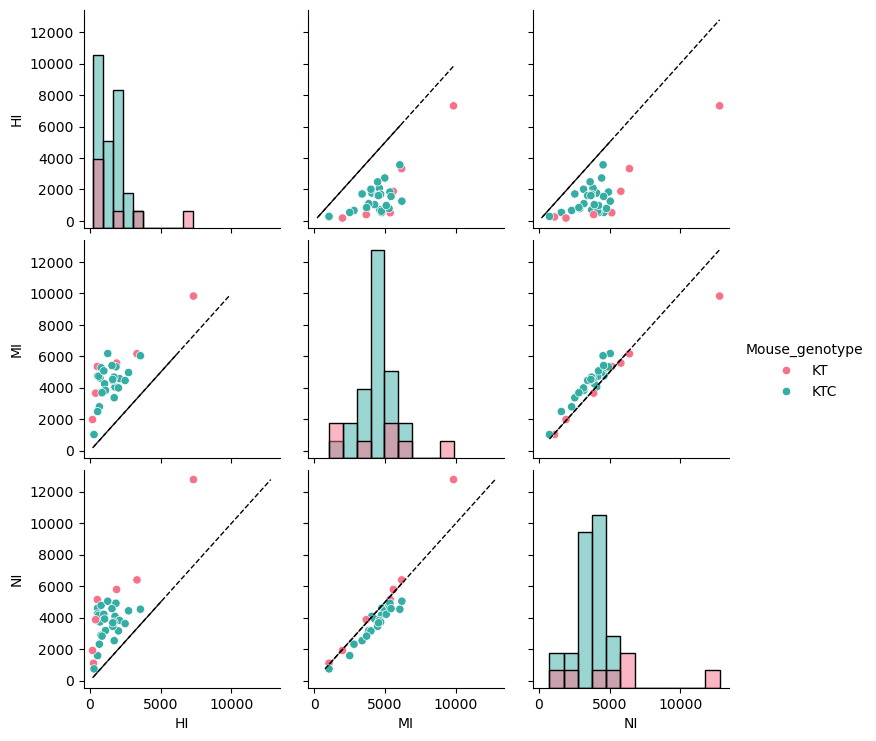

In [60]:
grid = sns.pairplot(re_shaped_df,hue="Mouse_genotype", palette="husl",diag_kind='hist')
grid.map_offdiag(plot_unity)

#### Total tumor burden

In [61]:
temp_df = Sample_summary_df2
re_shaped_df = pd.pivot_table(temp_df, values = 'TTB', index=['Sample_ID','Mouse_genotype'], columns = 'Vector_type').reset_index()

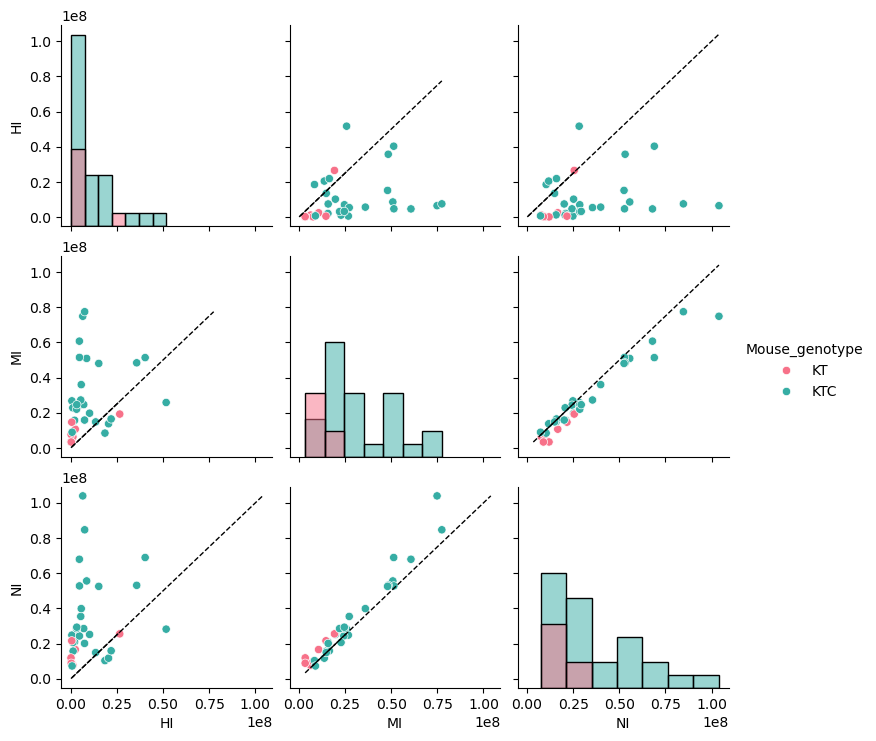

In [62]:
grid = sns.pairplot(re_shaped_df,hue="Mouse_genotype", palette="husl",diag_kind='hist')
grid.map_offdiag(plot_unity)

* <font size="5" color =  red> NI and MI tumor behave very similar across mice for both total tumor burdent and tumor initiation </font>
* <font size="5" color =  red> HI behavior does not correlated well with the other two. And both tumor initation and growth are inhibited</font>

### Tumor metrics distribution across 

Text(1.0, 1.0, 'B')

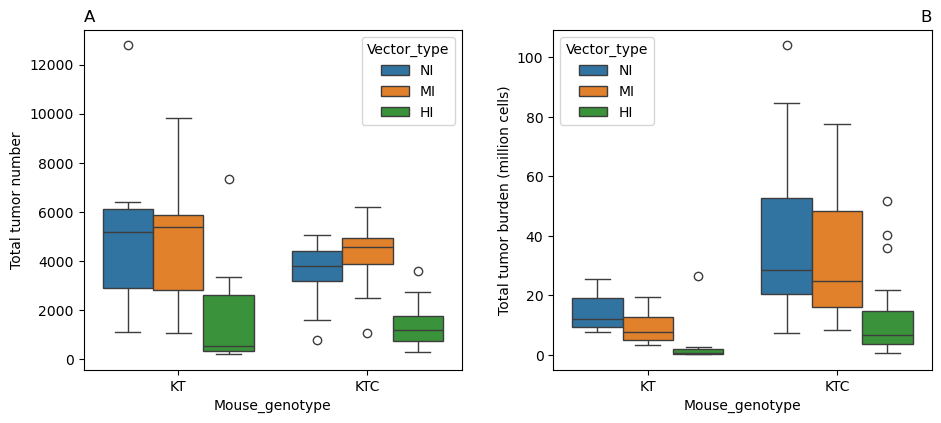

In [63]:
gs = gridspec.GridSpec(3, 17) 
fig1 = plt.figure(figsize=(17,15))

ax1=fig1.add_subplot(gs[:1, 0:5])
temp_df = Sample_summary_df2
# sns.boxplot(x='Virus_titer', y='TTB_million', data=Sample_summary_df, hue=Sample_summary_df[['Mouse_genotype','Sex']].apply(tuple, axis=1), ax= ax7)
sns.boxplot(x='Mouse_genotype', y='TTN', data=temp_df, hue='Vector_type', ax= ax1)
ax1.set_ylabel('Total tumor number')

ax1.set_title('A', loc ='left')


ax2=fig1.add_subplot(gs[:1, 6:11])
temp_df = Sample_summary_df2
# sns.boxplot(x='Virus_titer', y='TTB_million', data=Sample_summary_df, hue=Sample_summary_df[['Mouse_genotype','Sex']].apply(tuple, axis=1), ax= ax7)
sns.boxplot(x='Mouse_genotype', y='TTB_million', data=temp_df, hue='Vector_type', ax= ax2)
ax2.set_ylabel('Total tumor burden (million cells)') 
# ax6.set_yscale('log')
ax2.set_title('B', loc ='Right')